# Time-Metadata-Only Baseline (CLASSIFIER_v2)

**Question.** How much of the converter-vs-stable AUC is explainable by *temporal metadata alone* — number of visits, inter-visit intervals, age, sex — *without any fMRI data*?

**Method.** Build a tabular feature set from `cohorts.csv` and the cohort-policy splits, then fit `LogisticRegression` and `GradientBoostingClassifier` with `StratifiedGroupKFold(groups=subject_id)`.

**Interpretation.**
* Metadata-only CV AUC **> ~0.70** → temporal metadata is doing most of the work; headline results need to be re-stated *relative to this baseline*.
* Metadata-only CV AUC near 0.5 → the LSTM's signal genuinely comes from brain dynamics.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

V2_ROOT = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER_v2')
if str(V2_ROOT) not in sys.path:
    sys.path.insert(0, str(V2_ROOT))

from common.sanity import run_full_audit

In [2]:
DATA_VERSION = '__v3__'
DATA_ROOT    = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE') / DATA_VERSION
METADATA_DIR = DATA_ROOT / 'metadata'
COHORTS_CSV  = METADATA_DIR / 'cohorts.csv'

SPLIT_CSVS = {
    'train': str(METADATA_DIR / 'splits_gaae' / 'train.csv'),
    'val':   str(METADATA_DIR / 'splits_gaae' / 'val.csv'),
    'test':  str(METADATA_DIR / 'splits_gaae' / 'test.csv'),
}
RANDOM_STATE = 42
N_FOLDS = 5

# Fail loud if splits overlap before doing anything else.
_ = run_full_audit(SPLIT_CSVS)

[SANITY] Split sizes: {'train': 345, 'val': 69, 'test': 46}
[SANITY] Pairwise-disjoint: OK


## Build subject-level metadata features

Per subject:
* `n_visits`        — count of scans
* `mean_dt`         — mean inter-visit interval (months)
* `max_dt`          — max inter-visit interval (months)
* `total_followup`  — last visit month minus first
* `age`             — age at baseline
* `sex`             — 0=female, 1=male

*No fMRI features are used.* If a converter cohort tends to have a longer follow-up window, this baseline will catch it.

In [3]:
cohorts = pd.read_csv(COHORTS_CSV)
id_col = 'Pseudonym' if 'Pseudonym' in cohorts.columns else 'Repseudonym'
cohorts[id_col] = cohorts[id_col].astype(str)
cohorts['visit_m'] = cohorts['visit'].str.replace('M', '', regex=False).astype(float)

def build_metadata_features(subject_df, cohorts_df):
    out = []
    for _, row in subject_df.iterrows():
        pid = str(row['Repseudonym'])
        sub_visits = cohorts_df.loc[cohorts_df[id_col] == pid, 'visit_m'].dropna().sort_values()
        if len(sub_visits) == 0:
            continue
        months = sub_visits.to_numpy()
        diffs  = np.diff(months) if len(months) > 1 else np.array([0.0])
        out.append({
            'Repseudonym':    pid,
            'label':          1 if row['diagnosis'] == 'converter' else 0,
            'n_visits':       float(len(months)),
            'mean_dt':        float(diffs.mean()),
            'max_dt':         float(diffs.max()),
            'total_followup': float(months[-1] - months[0]),
            'age':            float(row.get('age', 0.0)) if pd.notna(row.get('age', None)) else 0.0,
            'sex':            1 if str(row.get('sex', 'f')).lower() == 'm' else 0,
        })
    return pd.DataFrame(out)

train_df = pd.read_csv(SPLIT_CSVS['train'])
val_df   = pd.read_csv(SPLIT_CSVS['val'])
test_df  = pd.read_csv(SPLIT_CSVS['test'])

cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
cv_pool_df = cv_pool_df[cv_pool_df['diagnosis'].isin(['mci', 'converter'])].copy()
test_mci   = test_df[test_df['diagnosis'].isin(['mci', 'converter'])].copy()

cv_meta   = build_metadata_features(cv_pool_df, cohorts)
test_meta = build_metadata_features(test_mci,   cohorts)

print(f'CV pool: {len(cv_meta)} subjects ({cv_meta["label"].sum()} converter)')
print(f'Test:    {len(test_meta)} subjects ({test_meta["label"].sum()} converter)')
cv_meta.head()

CV pool: 141 subjects (52 converter)
Test:    16 subjects (6 converter)


,Repseudonym,label,n_visits,mean_dt,max_dt,total_followup,age,sex
0,03a0a6663,1,5.0,12.0,12.0,48.0,79.0,1
1,04b06dc4d,0,2.0,12.0,12.0,12.0,79.0,1
2,04cbb28bb,0,7.0,12.0,12.0,72.0,78.0,0
3,05595022c,1,2.0,12.0,12.0,12.0,68.0,0
4,0588be6c5,1,3.0,12.0,12.0,24.0,71.0,0


## Class-conditional distribution of n_visits and Δt

If converters systematically have longer or more frequent follow-up, this is *direct* evidence of metadata leakage.

n_visits         stable: 4.26±2.68   converter: 5.21±1.81
mean_dt          stable: 10.29±4.56   converter: 12.48±1.78
max_dt           stable: 10.79±5.44   converter: 13.62±4.14
total_followup   stable: 39.64±32.23   converter: 51.92±21.35
age              stable: 79.15±5.65   converter: 81.02±6.08


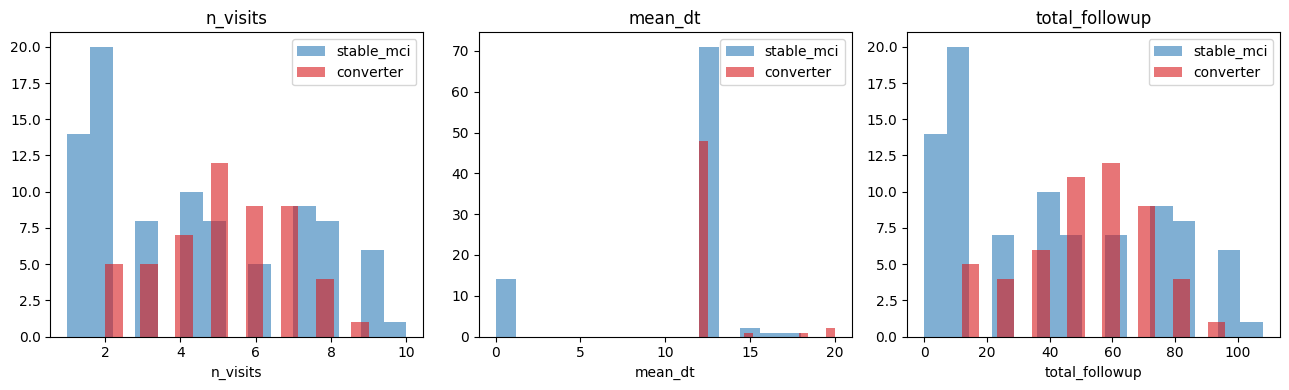

In [4]:
for col in ['n_visits', 'mean_dt', 'max_dt', 'total_followup', 'age']:
    stable    = cv_meta.loc[cv_meta['label'] == 0, col]
    converter = cv_meta.loc[cv_meta['label'] == 1, col]
    print(f'{col:<15}  stable: {stable.mean():.2f}±{stable.std():.2f}   '
          f'converter: {converter.mean():.2f}±{converter.std():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['n_visits', 'mean_dt', 'total_followup']):
    for label, name, color in [(0, 'stable_mci', '#2C7BB6'), (1, 'converter', '#D7191C')]:
        ax.hist(cv_meta.loc[cv_meta['label'] == label, col], bins=15, alpha=0.6, label=name, color=color)
    ax.set_title(col); ax.set_xlabel(col); ax.legend()
plt.tight_layout(); plt.show()

## CV: metadata-only logistic regression and gradient boosting

In [5]:
FEATURE_COLS = ['n_visits', 'mean_dt', 'max_dt', 'total_followup', 'age', 'sex']
X = cv_meta[FEATURE_COLS].to_numpy()
y = cv_meta['label'].to_numpy()
groups = cv_meta['Repseudonym'].to_numpy()

X_test = test_meta[FEATURE_COLS].to_numpy()
y_test = test_meta['label'].to_numpy()

def cv_auc(estimator_factory, X, y, groups, n_splits=5, seed=42, standardize=True):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_aucs = []
    oof = np.zeros(len(y))
    for tr, va in sgkf.split(X, y, groups=groups):
        if standardize:
            sc = StandardScaler().fit(X[tr])
            X_tr, X_va = sc.transform(X[tr]), sc.transform(X[va])
        else:
            X_tr, X_va = X[tr], X[va]
        clf = estimator_factory()
        clf.fit(X_tr, y[tr])
        p = clf.predict_proba(X_va)[:, 1]
        oof[va] = p
        fold_aucs.append(roc_auc_score(y[va], p))
    return np.array(fold_aucs), oof

models = {
    'LogReg':       lambda: LogisticRegression(max_iter=2000, class_weight='balanced'),
    'GradBoosting': lambda: GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, factory in models.items():
    aucs, oof = cv_auc(factory, X, y, groups, n_splits=N_FOLDS, seed=RANDOM_STATE,
                       standardize=(name == 'LogReg'))
    # Held-out test (refit on full CV pool)
    if name == 'LogReg':
        sc = StandardScaler().fit(X)
        clf = factory().fit(sc.transform(X), y)
        p_test = clf.predict_proba(sc.transform(X_test))[:, 1]
    else:
        clf = factory().fit(X, y)
        p_test = clf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else float('nan')
    rows.append({
        'model':     name,
        'cv_auc_mean': float(aucs.mean()),
        'cv_auc_std':  float(aucs.std()),
        'test_auc':    float(test_auc),
        'oof_auc':     float(roc_auc_score(y, oof)),
    })

results = pd.DataFrame(rows)
results

,model,cv_auc_mean,cv_auc_std,test_auc,oof_auc
0,LogReg,0.642406,0.023843,0.566667,0.643366
1,GradBoosting,0.666717,0.069819,0.683333,0.664758


## Headline number

Quote the **metadata-only CV AUC** alongside every fMRI-based AUC in the final paper table. If the LSTM beats it by < 0.05, the marginal contribution of brain dynamics is small and the headline framing must change.

In [6]:
best_meta_auc = results['cv_auc_mean'].max()
print(f'Best metadata-only CV AUC: {best_meta_auc:.4f}')
print('Compare against GELSTM CV AUC (current: 0.944 ± 0.058)')

Best metadata-only CV AUC: 0.6667
Compare against GELSTM CV AUC (current: 0.944 ± 0.058)


In [ ]:

import json
from pathlib import Path

_out = Path(__file__).parent if '__file__' in dir() else Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER_v2/notebooks')
METADATA_BASELINE_JSON = _out / 'metadata_baseline_results.json'

best_row = results.loc[results['cv_auc_mean'].idxmax()]
_payload = {
    'best_model':    best_row['model'],
    'cv_auc_mean':   best_row['cv_auc_mean'],
    'cv_auc_std':    best_row['cv_auc_std'],
    'test_auc':      best_row['test_auc'],
    'all_models':    results.to_dict(orient='records'),
}
with open(METADATA_BASELINE_JSON, 'w') as f:
    json.dump(_payload, f, indent=2)
print(f'Saved metadata baseline results → {METADATA_BASELINE_JSON}')
print(f"  best model : {_payload['best_model']}")
print(f"  cv_auc     : {_payload['cv_auc_mean']:.4f} ± {_payload['cv_auc_std']:.4f}")
print(f"  test_auc   : {_payload['test_auc']:.4f}")
